# NIDS Adversarial Robustness — Analiza wyników

Notebook łączy `results_unsw.csv` i `results_cic.csv` i generuje:
1. Accuracy vs ε (dla każdego modelu × obrona)
2. ASR vs ε
3. Porównanie z/bez adversarial training
4. Czas wnioskowania
5. Porównanie z artykułem (UNSW-NB15)

In [2]:
import sys, os
sys.path.insert(0, os.path.join('..'))  # żeby importy config działały

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [3]:
unsw = pd.read_csv('../results/results_unsw.csv')
cic  = pd.read_csv('../results/results_cic.csv')
df   = pd.concat([unsw, cic], ignore_index=True)
df.head()

,dataset,model,defense,eps,accuracy,precision,recall,f1,auc,asr,infer_time_ms,n_test,seed
0,unsw,rf,none,0.00,0.8911,0.8477,0.9780,0.9082,0.9824,NaN,52.68,82332,42
1,unsw,rf,none,0.01,0.7227,0.6871,0.9114,0.7835,0.7071,0.0802,42.13,82332,42
2,unsw,rf,none,0.05,0.5912,0.6145,0.6913,0.6506,0.6227,0.3043,37.90,82332,42
3,unsw,rf,none,0.10,0.4347,0.4888,0.5809,0.5309,0.4489,0.4173,40.51,82332,42
4,unsw,rf,none,0.15,0.3566,0.4350,0.5637,0.4910,0.3262,0.4357,39.07,82332,42


## 1. Accuracy vs ε

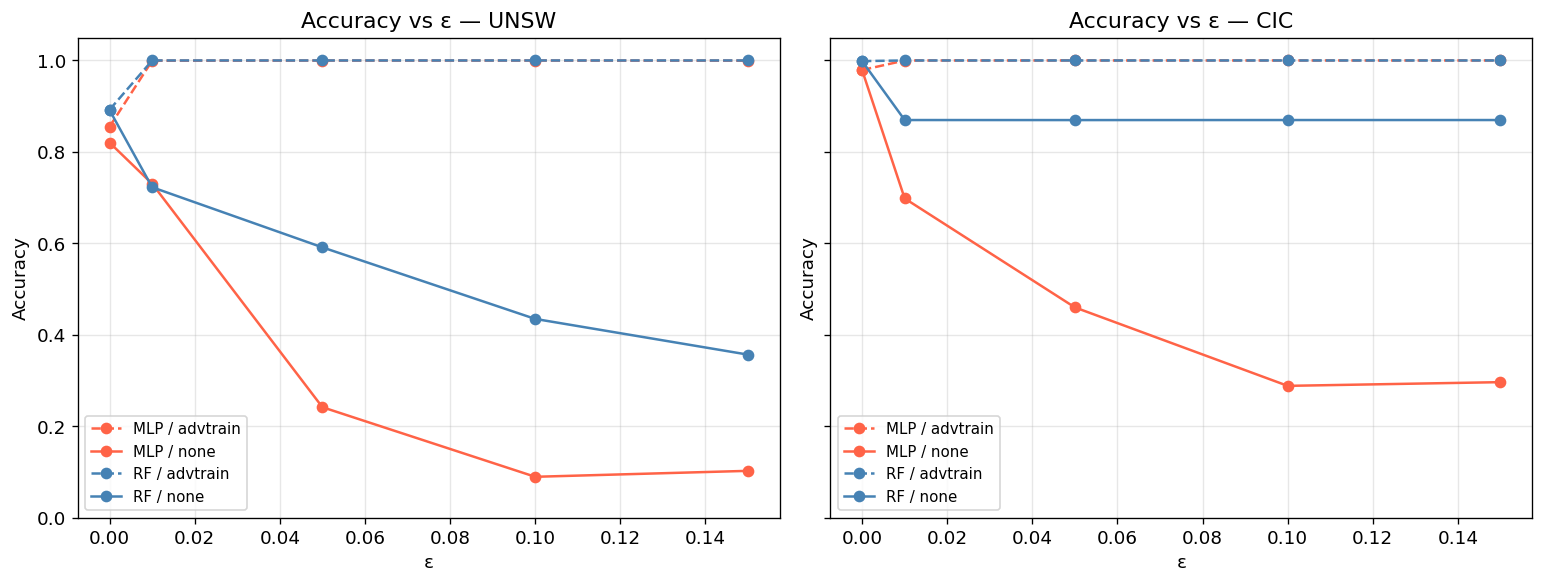

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, dataset in zip(axes, ['unsw', 'cic']):
    sub = df[df['dataset'] == dataset]
    for (model, defense), grp in sub.groupby(['model', 'defense']):
        label = f"{model.upper()} / {defense}"
        style = '--' if defense == 'advtrain' else '-'
        color = 'steelblue' if model == 'rf' else 'tomato'
        ax.plot(grp['eps'], grp['accuracy'], style, color=color, label=label, marker='o')
    ax.set_title(f"Accuracy vs ε — {dataset.upper()}")
    ax.set_xlabel('ε')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../results/fig_accuracy_vs_eps.png', bbox_inches='tight')
plt.show()

## 2. ASR vs ε

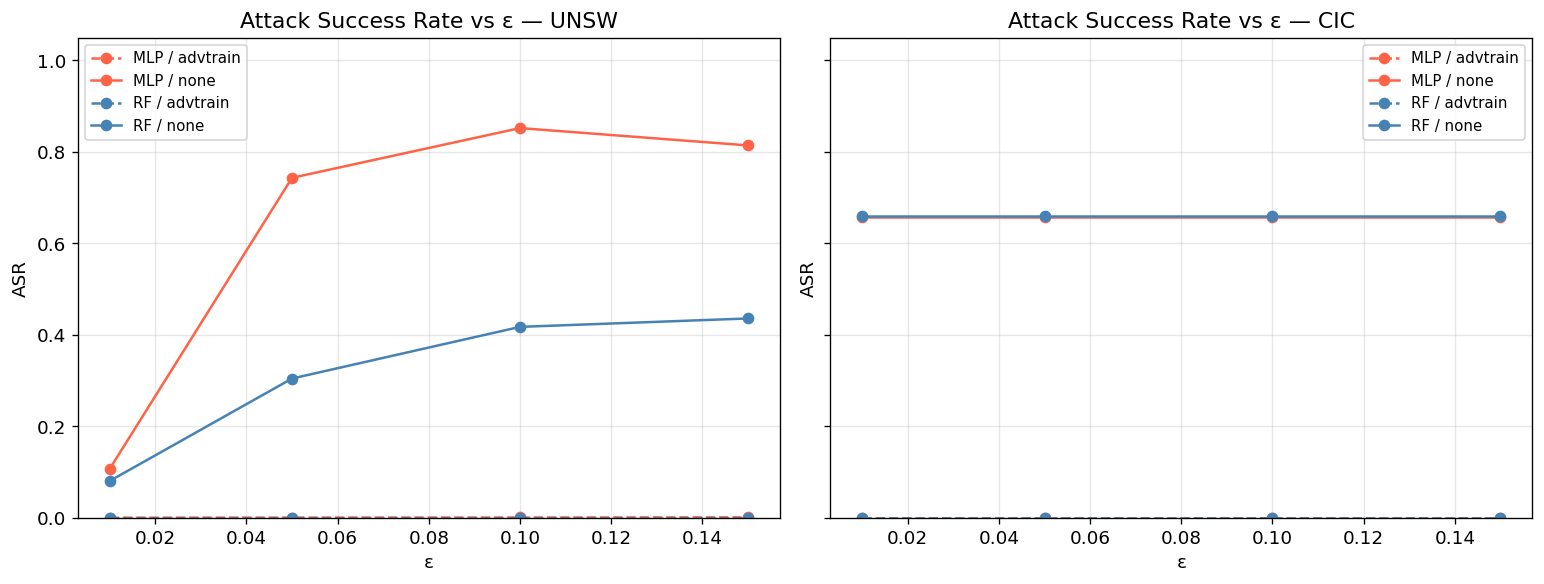

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, dataset in zip(axes, ['unsw', 'cic']):
    sub = df[(df['dataset'] == dataset) & (df['eps'] > 0)]
    for (model, defense), grp in sub.groupby(['model', 'defense']):
        label = f"{model.upper()} / {defense}"
        style = '--' if defense == 'advtrain' else '-'
        color = 'steelblue' if model == 'rf' else 'tomato'
        ax.plot(grp['eps'], grp['asr'], style, color=color, label=label, marker='o')
    ax.set_title(f"Attack Success Rate vs ε — {dataset.upper()}")
    ax.set_xlabel('ε')
    ax.set_ylabel('ASR')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../results/fig_asr_vs_eps.png', bbox_inches='tight')
plt.show()

## 3. Adversarial training — efekt obrony (F1)

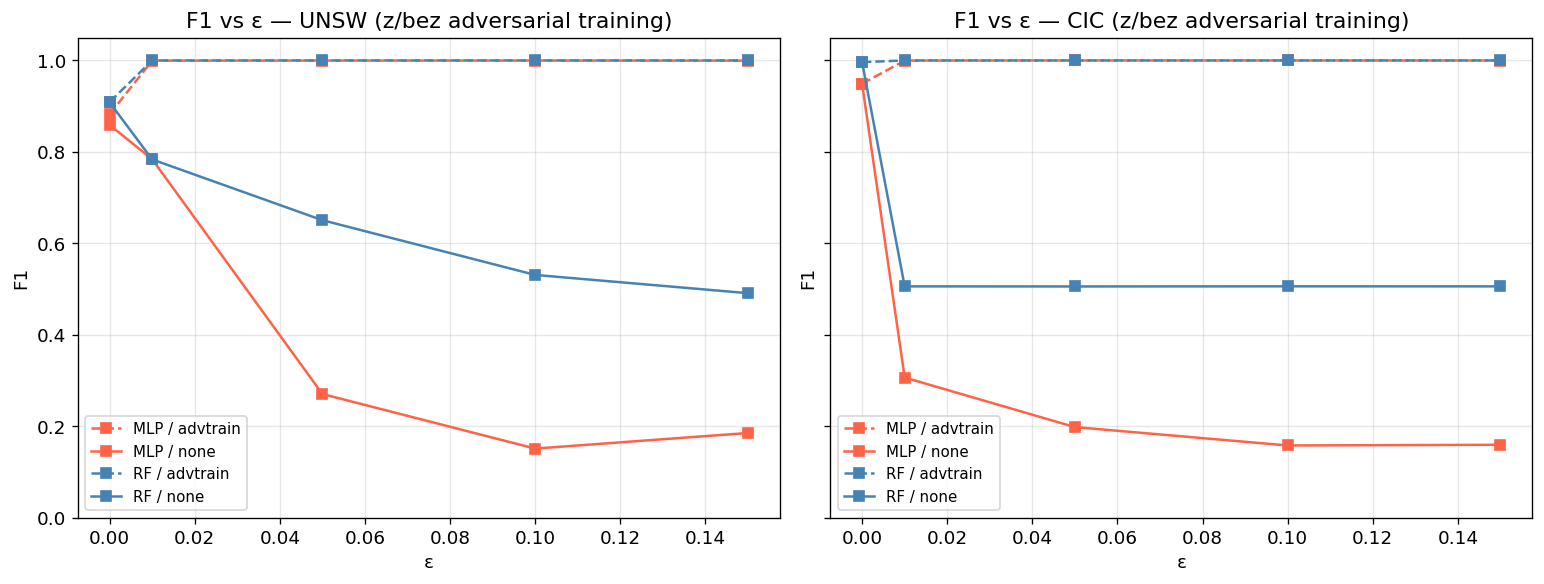

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, dataset in zip(axes, ['unsw', 'cic']):
    sub = df[df['dataset'] == dataset]
    for (model, defense), grp in sub.groupby(['model', 'defense']):
        label = f"{model.upper()} / {defense}"
        style = '--' if defense == 'advtrain' else '-'
        color = 'steelblue' if model == 'rf' else 'tomato'
        ax.plot(grp['eps'], grp['f1'], style, color=color, label=label, marker='s')
    ax.set_title(f"F1 vs ε — {dataset.upper()} (z/bez adversarial training)")
    ax.set_xlabel('ε')
    ax.set_ylabel('F1')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../results/fig_f1_advtrain.png', bbox_inches='tight')
plt.show()

## 4. Czas wnioskowania

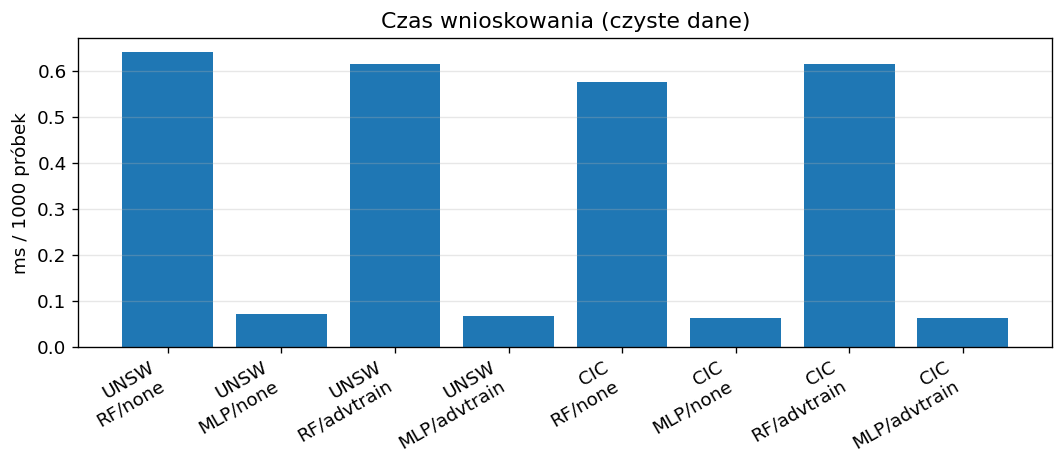

In [7]:
time_df = df[df['eps'] == 0.0][['dataset', 'model', 'defense', 'infer_time_ms', 'n_test']].copy()
time_df['ms_per_1k'] = time_df['infer_time_ms'] / time_df['n_test'] * 1000

fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{r['dataset'].upper()}\n{r['model'].upper()}/{r['defense']}" for _, r in time_df.iterrows()]
ax.bar(range(len(time_df)), time_df['ms_per_1k'], tick_label=labels)
ax.set_ylabel('ms / 1000 próbek')
ax.set_title('Czas wnioskowania (czyste dane)')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/fig_infer_time.png', bbox_inches='tight')
plt.show()

## 5. Porównanie z artykułem (UNSW-NB15)

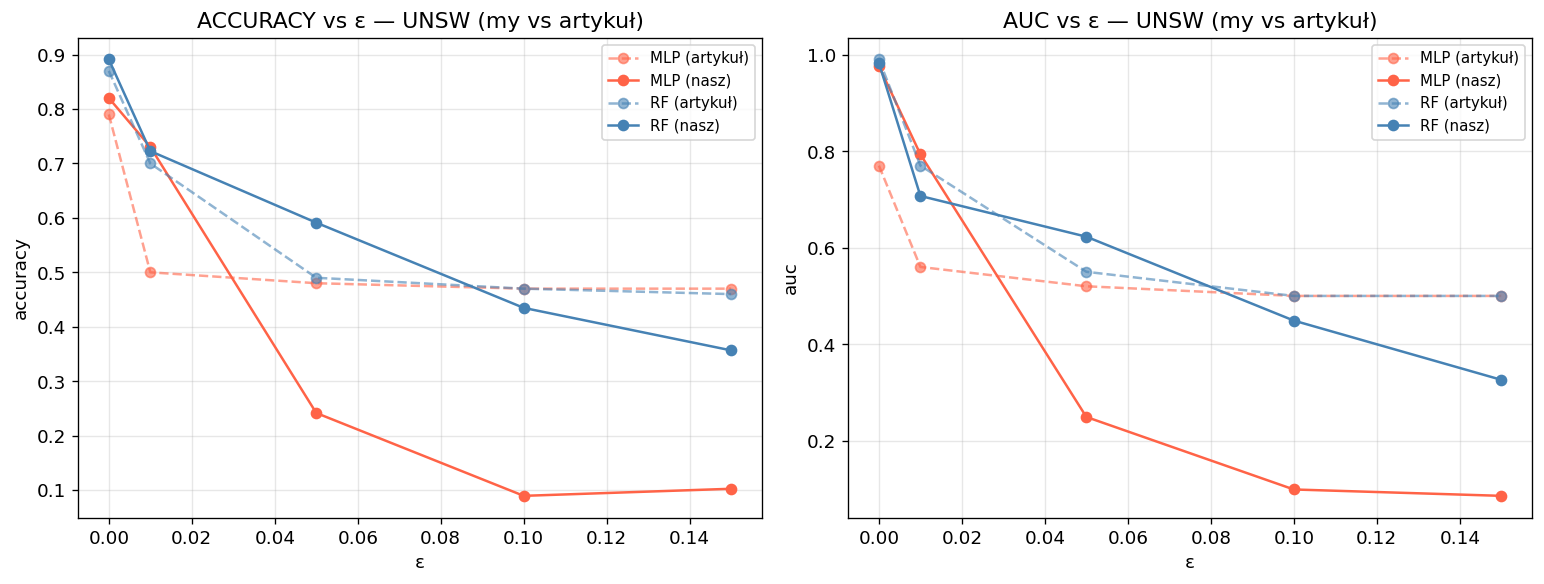

In [8]:
# Wyniki z artykułu Heydari & Nyarko (ICEIS 2025)
paper = pd.DataFrame([
    {'model': 'rf',  'eps': 0.00, 'accuracy': 0.87, 'auc': 0.99, 'source': 'artykuł'},
    {'model': 'mlp', 'eps': 0.00, 'accuracy': 0.79, 'auc': 0.77, 'source': 'artykuł'},
    {'model': 'rf',  'eps': 0.01, 'accuracy': 0.70, 'auc': 0.77, 'source': 'artykuł'},
    {'model': 'mlp', 'eps': 0.01, 'accuracy': 0.50, 'auc': 0.56, 'source': 'artykuł'},
    {'model': 'rf',  'eps': 0.05, 'accuracy': 0.49, 'auc': 0.55, 'source': 'artykuł'},
    {'model': 'mlp', 'eps': 0.05, 'accuracy': 0.48, 'auc': 0.52, 'source': 'artykuł'},
    {'model': 'rf',  'eps': 0.10, 'accuracy': 0.47, 'auc': 0.50, 'source': 'artykuł'},
    {'model': 'mlp', 'eps': 0.10, 'accuracy': 0.47, 'auc': 0.50, 'source': 'artykuł'},
    {'model': 'rf',  'eps': 0.15, 'accuracy': 0.46, 'auc': 0.50, 'source': 'artykuł'},
    {'model': 'mlp', 'eps': 0.15, 'accuracy': 0.47, 'auc': 0.50, 'source': 'artykuł'},
])

ours = df[(df['dataset'] == 'unsw') & (df['defense'] == 'none')][['model','eps','accuracy','auc']].copy()
ours['source'] = 'nasz'

compare = pd.concat([paper, ours], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['accuracy', 'auc']):
    for (model, source), grp in compare.groupby(['model', 'source']):
        style = '--' if source == 'artykuł' else '-'
        color = 'steelblue' if model == 'rf' else 'tomato'
        alpha = 0.6 if source == 'artykuł' else 1.0
        ax.plot(grp['eps'], grp[metric], style, color=color,
                label=f"{model.upper()} ({source})", marker='o', alpha=alpha)
    ax.set_title(f"{metric.upper()} vs ε — UNSW (my vs artykuł)")
    ax.set_xlabel('ε')
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/fig_comparison_paper.png', bbox_inches='tight')
plt.show()

## 6. Tabela zbiorcza

In [9]:
pd.set_option('display.float_format', '{:.4f}'.format)
df[['dataset','model','defense','eps','accuracy','f1','auc','asr','infer_time_ms']]

,dataset,model,defense,eps,accuracy,f1,auc,asr,infer_time_ms
0,unsw,rf,none,0.0000,0.8911,0.9082,0.9824,NaN,52.6800
1,unsw,rf,none,0.0100,0.7227,0.7835,0.7071,0.0802,42.1300
2,unsw,rf,none,0.0500,0.5912,0.6506,0.6227,0.3043,37.9000
3,unsw,rf,none,0.1000,0.4347,0.5309,0.4489,0.4173,40.5100
4,unsw,rf,none,0.1500,0.3566,0.4910,0.3262,0.4357,39.0700
5,unsw,mlp,none,0.0000,0.8202,0.8589,0.9758,NaN,5.9400
6,unsw,mlp,none,0.0100,0.7303,0.7839,0.7932,0.1064,5.9100
7,unsw,mlp,none,0.0500,0.2416,0.2704,0.2492,0.7433,5.8700
8,unsw,mlp,none,0.1000,0.0894,0.1511,0.0990,0.8521,5.8300
9,unsw,mlp,none,0.1500,0.1024,0.1852,0.0858,0.8142,5.9400
